In [98]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.pipeline import  Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler,OneHotEncoder,OrdinalEncoder
from sklearn.tree import DecisionTreeClassifier,DecisionTreeRegressor
from sklearn.ensemble import  RandomForestRegressor
from sklearn.ensemble import BaggingRegressor
from  sklearn.metrics import r2_score
import seaborn as sns
from sklearn.svm import  SVR

In [99]:
df=pd.read_csv('train1.csv')

In [100]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38199 entries, 0 to 38198
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   id            38199 non-null  int64  
 1   brand         38199 non-null  int64  
 2   model_id      38199 non-null  int64  
 3   year          38199 non-null  int64  
 4   transmission  38199 non-null  object 
 5   fuelType      38199 non-null  object 
 6   mileage       38199 non-null  int64  
 7   tax           38199 non-null  int64  
 8   mpg           38199 non-null  float64
 9   engineSize    38199 non-null  float64
 10  price         38199 non-null  int64  
dtypes: float64(2), int64(7), object(2)
memory usage: 3.2+ MB


In [101]:
df.shape

(38199, 11)

In [102]:
df.head()

,id,brand,model_id,year,transmission,fuelType,mileage,tax,mpg,engineSize,price
0,53394,3,17,2019,Automatic,Diesel,7148,145,50.4,2.0,29990
1,27771,2,44,2018,Manual,Diesel,19254,150,60.1,2.0,15750
2,22402,2,33,2017,Manual,Petrol,13275,145,60.1,1.0,10400
3,29944,2,32,2018,Manual,Petrol,20106,145,65.7,1.0,10595
4,47602,3,53,2013,Manual,Petrol,61984,125,51.4,1.2,6191


In [103]:
df['transmission'].unique()

array(['Automatic', 'Manual', 'Semi-Auto'], dtype=object)

In [104]:
df['fuelType'].unique()

array(['Diesel', 'Petrol', 'Hybrid', 'Other', 'Electric'], dtype=object)

In [105]:
x=df.drop('price',axis=1)
y=df.price

In [106]:
xtrain,xtest,ytrain,ytest=train_test_split(x,y,train_size=0.8,random_state=42)

In [107]:
num_col=xtrain.select_dtypes(include='number').columns
obj_col=xtrain.select_dtypes(exclude='number').columns

<Axes: >

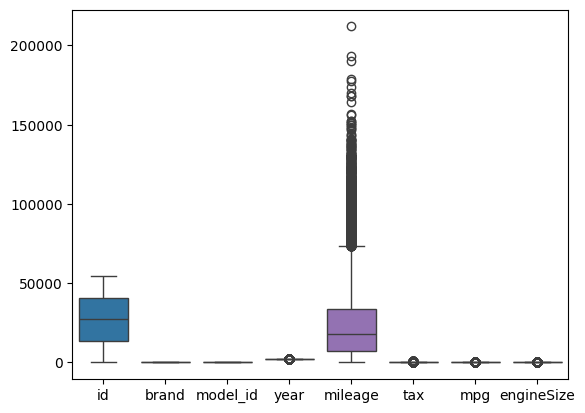

In [108]:
sns.boxplot(df[num_col])

In [109]:
preprocessing=ColumnTransformer(
    transformers=[
        ('scaler',StandardScaler(),num_col),
        ('onehotencoder',OneHotEncoder(sparse_output=False,handle_unknown='ignore'),obj_col)
        
    ]
)

In [110]:
decisiontree_pipeline=Pipeline(
    steps=[
('preprocessing',preprocessing),
('model',DecisionTreeRegressor())
    ]
)

In [111]:
decisiontree_pipeline.fit(xtrain,ytrain)

,steps,"[('preprocessing', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('scaler', ...), ('onehotencoder', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [112]:
print("Train_score:",decisiontree_pipeline.score(xtrain,ytrain))
print("Test_score:",decisiontree_pipeline.score(xtest,ytest))

Train_score: 1.0
Test_score: 0.9287610258490477


In [113]:
Random_forest_pipeline=Pipeline(
    steps=[
('preprocessing',preprocessing),
('model',RandomForestRegressor())
    ]
)

In [114]:
Random_forest_pipeline.fit(xtrain,ytrain)

,steps,"[('preprocessing', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('scaler', ...), ('onehotencoder', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [115]:
print("train_score:",Random_forest_pipeline.score(xtrain,ytrain))
print("test_score:",Random_forest_pipeline.score(xtest,ytest))

train_score: 0.9934330191883004
test_score: 0.9613707540478403


In [116]:
rfr=Random_forest_pipeline.named_steps['model']   #to select the perticular steps which is present in pipeline
rfr.fit(xtrain[num_col],ytrain)


,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [118]:
bagging_pipeline=Pipeline(
    steps=[
('preprocessing',preprocessing),
('model',BaggingRegressor(estimator=SVR()))
    ]
)

'''RandomForestRegressior:- by default it uses - n estimator: Int=100-
base estimator is Decision Treee
if max_features is 2(total 5 features)
randomly selects 2 and checks which feature from max_feaures=2
example:-
feature1,feature2,feature3,feature4,feature5
max_feaures=2
randomly selects 2 => feature 1,feature 4
selected feature for rootnode is feature 1(random)
'''

'''BaggingReggressor:- by default it uses-n estimator : Int=10
base estimator is None by default and we can use Decision Tree,SVM,KNN,Naivebayes(Bagging classifier)

if max_features is 2(total 5 features)
randomly selects 2 and checks which feature(IG/Gini Impurity) is best.
'''

'BaggingReggressor:- by default it uses-n estimator : Int=10\nbase estimator is None by default and we can use Decision Tree,SVM,KNN,Naivebayes(Bagging classifier)\n\nif max_features is 2(total 5 features)\nrandomly selects 2 and checks which feature(IG/Gini Impurity) is best.\n'

In [119]:
bagging_pipeline.fit(xtrain,ytrain)

,steps,"[('preprocessing', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('scaler', ...), ('onehotencoder', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [123]:
print("train_score:",bagging_pipeline.score(xtrain,ytrain))
print("test_score:",bagging_pipeline.score(xtest,ytest))

train_score: 0.20411956029215383
test_score: 0.20983840593685432


In [ ]:
# bagging_pipeline=Pipeline(
#     steps=[
# ('preprocessing',preprocessing),
# ('model',BaggingRegressor(estimator=DecisionTreeRegressor()))
#     ]
# )

**Test.csv**

In [ ]:
df1=pd.read_csv("test1.csv")

In [ ]:
df1.head()

,id,brand,model_id,year,transmission,fuelType,mileage,tax,mpg,engineSize
0,52462,3,74,2016,Manual,Diesel,31353.819030,20.633243,58.036574,1.918948
1,29710,2,86,2019,Manual,Diesel,10799.605446,138.093173,30.926330,1.941589
2,21277,1,2,2017,Manual,Diesel,27927.369180,30.814931,63.850549,2.043908
3,31612,2,32,2018,Manual,Petrol,16826.328276,149.173033,63.126677,1.027988
4,53244,3,83,2016,Automatic,Diesel,47322.677929,230.067187,41.854266,2.864245


In [ ]:
predict_values=decisiontree_pipeline.predict(df1)

In [ ]:
ypred=Random_forest_pipeline.predict(df1)

In [ ]:
id=df1['id']

In [ ]:
dtest=decisiontree_pipeline.predict(xtest)

In [ ]:
rtest=Random_forest_pipeline.predict(xtest)

In [ ]:
r2_score(ytest,dtest)

0.9261605712588004

In [ ]:
r2_score(ytest,rtest)

0.9609962761318592

In [ ]:
new_df=pd.DataFrame({'id':id,'decison_predict_values':predict_values,'random_ypred':ypred})
new_df

,id,decison_predict_values,random_ypred
0,52462,14698.0,14674.34
1,29710,26922.0,27452.73
2,21277,15500.0,14869.41
3,31612,12995.0,12815.62
4,53244,19300.0,20510.97
...,...,...,...
16367,37536,9295.0,9590.08
16368,53520,19899.0,20263.81
16369,48008,11200.0,10618.95
16370,6295,38990.0,37526.69


In [ ]:
new_df.to_csv('vehicle_submission.csv')